<a href="https://colab.research.google.com/github/roneshpra/PythonLearning/blob/Dev/PythonBasics/M6W3_Project_HelmNet_Final_RB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [310]:
!pip install tensorflow[and-cuda] "numpy<2.1,>=2" -q
#!pip install numpy==1.25.2 pandas==2.0.3 seaborn==0.13.1 tensorflow==2.15.0 scikit-learn==1.2.2 matplotlib==3.7.1 -q

In [311]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.19.0


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [312]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [313]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# **Data Overview**


##Loading the data

In [314]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [315]:
# Load the image file of the dataset
images = np.load('/content/drive/MyDrive/images_proj.npy')
labels = pd.read_csv('/content/drive/MyDrive/Labels_proj.csv')

#### Print the shape of the images and labels

In [316]:
print(images.shape)
print(labels.shape)

(631, 200, 200, 3)
(631, 1)


* There are 631 RGB images of shape 200 x 200 x 3, each image having 3 channels

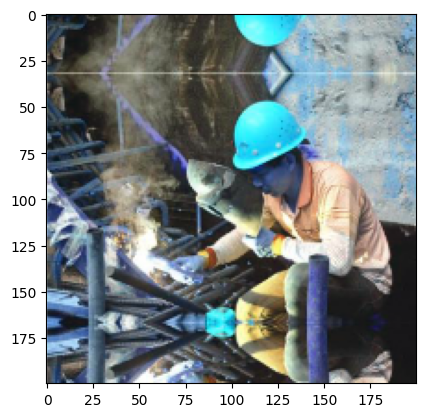

In [317]:
plt.imshow(images[1]);

* An image of a person with helmet

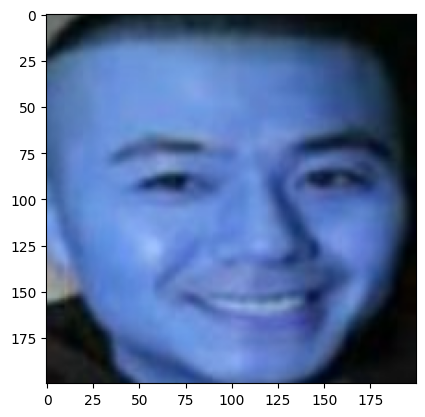

In [318]:
plt.imshow(images[320]);

* An image of a person without helmet

In [319]:
labels.iloc[:, 0].value_counts()

,count
Label,
0,320
1,311


* There are 320 images without helmet
* There are 311 images with helmet

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

In [320]:
helmet_indices = np.where(labels == 1)[0]
print("With Helmet: \n", helmet_indices)

With Helmet: 
 [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242

In [321]:
no_helmet_indices = np.where(labels == 0)[0]
print("Without Helmet: \n", no_helmet_indices)

Without Helmet: 
 [271 272 273 274 275 276 277 278 279 280 281 282 283 284 285 286 287 288
 289 290 291 292 293 294 295 296 297 298 299 300 301 302 303 304 305 306
 307 308 309 310 311 312 313 314 315 316 317 318 319 320 321 322 323 324
 325 326 327 328 329 330 331 332 333 334 335 336 337 338 339 340 341 342
 343 344 345 346 347 348 349 350 351 352 353 354 355 356 357 358 359 360
 361 362 363 364 365 366 367 368 369 370 371 372 373 374 375 376 377 378
 379 380 381 382 383 384 385 386 387 388 389 390 391 392 393 394 395 396
 397 398 399 400 401 402 403 404 405 406 407 408 409 410 411 412 413 414
 415 416 417 418 419 420 421 422 423 424 425 426 427 428 429 430 431 432
 433 434 435 436 437 438 439 440 441 442 443 444 445 446 447 448 449 450
 451 452 453 454 455 456 457 458 459 460 461 462 463 464 465 466 467 468
 469 470 471 472 473 474 475 476 477 478 479 480 481 482 483 484 485 486
 487 488 489 490 491 492 493 494 495 496 497 498 499 500 501 502 503 504
 505 506 507 508 509 510 511 512 

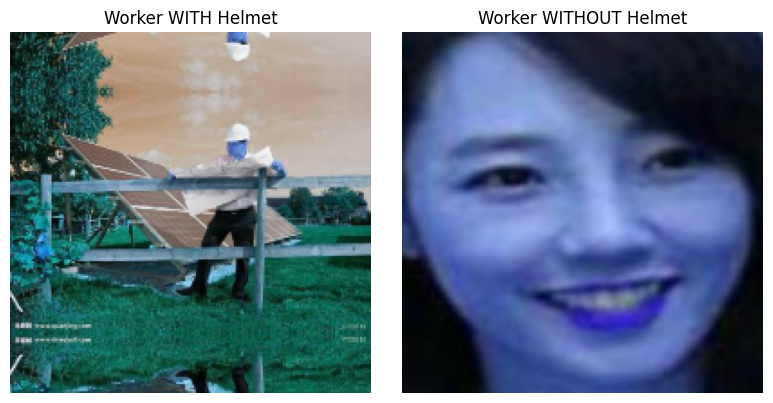

In [322]:

# Select one image from each class
helmet_img = images[np.random.choice(helmet_indices)]
no_helmet_img = images[np.random.choice(no_helmet_indices)]

# Plot the images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Display "With Helmet" image
axes[0].imshow(helmet_img)
axes[0].set_title("Worker WITH Helmet")
axes[0].axis('off')

# Display "Without Helmet" image
axes[1].imshow(no_helmet_img)
axes[1].set_title("Worker WITHOUT Helmet")
axes[1].axis('off')

# Show the plots
plt.tight_layout()
plt.show()

## Checking for class imbalance


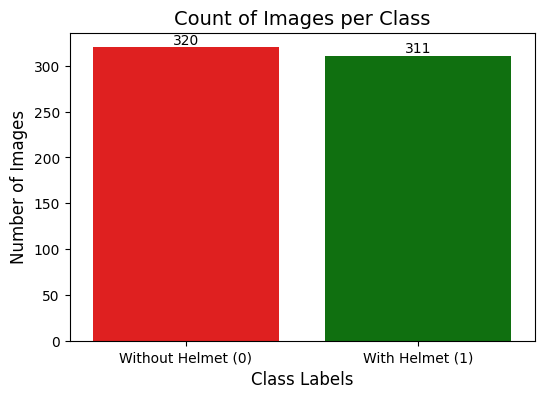

In [323]:
# Create a count plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=labels.iloc[:, 0], palette=['red', 'green'])

# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, )

# Add labels
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Count of Images per Class", fontsize=14)
plt.xticks(ticks=[0, 1], labels=["Without Helmet (0)", "With Helmet (1)"])  # Rename x-axis labels

# Show plot
plt.show()

* The dataset is pretty balanced

# **Data Preprocessing**

## Converting images to grayscale

In [324]:
# Function to plot the original and processed images side by side
def grid_plot(img1,img2,gray=False):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img1)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    if gray:
      axes[1].imshow(img2,cmap='gray')
    else:
      axes[1].imshow(img2)
    axes[1].set_title('Grayscale Image')
    axes[1].axis('off')

    plt.show()

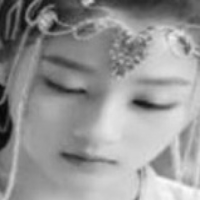

In [325]:
images_gray = []
for i in range(len(images)):
    img_gray = cv2.cvtColor(images[i], cv2.COLOR_RGB2GRAY)  # Convert to grayscale
    images_gray.append(img_gray)

# Display a sample grayscale image
n = 369  #Complete the code to define an index value
cv2_imshow(images_gray[n])

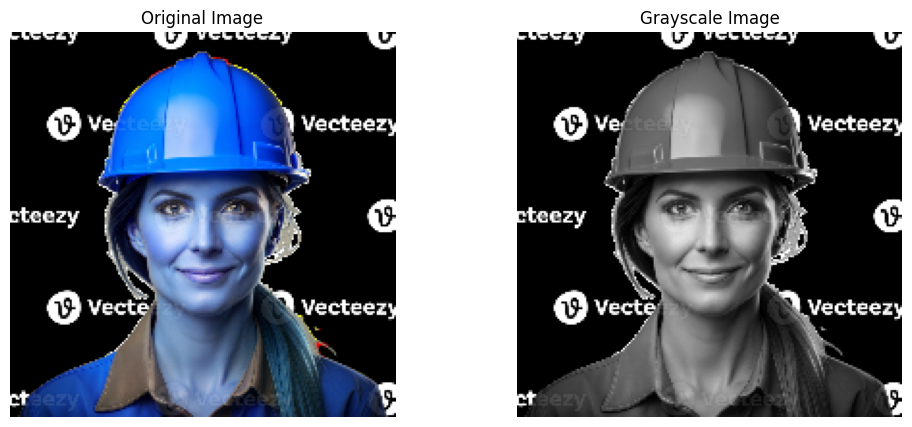

In [326]:
# Display a sample  original image and grayscale image

# choose an image
n = 111
grid_plot(images[n], images_gray[n],gray=True)

### Splitting the dataset



* As we have less images in our dataset, we will use 10% of our data for testing, 10% of our data for validation and 80% of our data for training
* We will be using train_test_split() function from scikit-learn. We will split the dataset into 3 parts, train, validation and test

In [327]:
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images),labels , test_size=0.2, random_state=42,stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp)

In [328]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(504, 200, 200, 3) (504, 1)
(63, 200, 200, 3) (63, 1)
(64, 200, 200, 3) (64, 1)


### Encoding the target labels

* Convert labels from names to one hot vectors

In [329]:
from sklearn.preprocessing import LabelBinarizer
enc = LabelBinarizer()
y_train_encoded = enc.fit_transform(y_train)
y_val_encoded=enc.transform(y_val)
y_test_encoded=enc.transform(y_test)

In [330]:
y_train_encoded[0]

array([1])

### Data Normalization

Since the **image pixel values range from 0-255**, our method of normalization here will be **scaling** - we shall **divide all the pixel values by 255 to standardize the images to have values between 0-1.**

In [331]:
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

# **Model Building**

## Utility Functions

In [332]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [333]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Simple Convolutional Neural Network (CNN)

Let's build a **CNN Model**.<br>

The model has 2 main parts:
1. **The Feature Extraction layers** which are comprised of convolutional and pooling layers.
2. **The Fully Connected classification layers for prediction.**<br><br>

In [334]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [335]:
# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [336]:
# Initializing Model
model_1 = Sequential()

# Convolutional layers
# Adding first convolutional layer with 64 filters and kernel size 3x3, padding 'same' provides the output size same as input size
model_1.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(200,200,3)))

# Adding max pooling to reduce the size of output of the 1st convolutional layer
model_1.add(MaxPooling2D((2, 2), padding='same'))

model_1.add(Conv2D(32, (3,3), activation='relu', padding="same"))
model_1.add(MaxPooling2D((2,2), padding='same'))
model_1.add(Conv2D(32, (3,3), activation='relu', padding="same"))

# Flatten and Dense layers
model_1.add(Flatten())

# Adding a fully connected dense layer with 32 neurons
model_1.add(Dense(32, activation='relu'))

# Adding 1 neuron for output layer with activation function as sigmoid since this is a binary classification
model_1.add(Dense(1, activation='sigmoid'))

# Compile with Adam Optimizer
opt = Adam(learning_rate=0.00001)

model_1.compile(optimizer=opt, loss='binary_crossentropy', metrics=["accuracy"])

# Summary
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     2,560,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,569 (9.88 MB)

 Trainable params: 2,589,569 (9.88 MB)

 Non-trainable params: 0 (0.00 B)

#### Parameters in the CNN Layers:

* 1st Conv2d Layer

  Input Shape : 200, 200, 3

  Filter Size : 3x3

  Number of parameters : (3x3x3 + 1)x64 = 1792

  (Filter Size x No. of channels + bias) x No. of Filters


* Max Pooling Layer

  There are no trainable parameters, so number of parameters is 0

* Flattening

  Number of parameters is 0 since there are no trainable parameters

* Fully Connected Layer

  Number of Neurons : 32

  Number of Parameters : (32 x 80000) + (1 x 32) = 2560032

  (No. of Neurons x No. of Neurons from previous layer) + ( bias x No. of Neurons)


* Output Layer

  Number of Neurons : 1
  
  Number of Parameters : (1 x 32) + (1 x 1) = 33

In [337]:
# Epochs
epochs = 15
# Batch size
batch_size = 128

history_1 = model_1.fit(
            X_train_normalized, y_train,
            epochs=epochs,
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=batch_size,
            verbose=2
)

Epoch 1/15
4/4 - 13s - 3s/step - accuracy: 0.5992 - loss: 0.6857 - val_accuracy: 0.9048 - val_loss: 0.6723
Epoch 2/15
4/4 - 3s - 804ms/step - accuracy: 0.9147 - loss: 0.6657 - val_accuracy: 0.8889 - val_loss: 0.6521
Epoch 3/15
4/4 - 2s - 553ms/step - accuracy: 0.9167 - loss: 0.6460 - val_accuracy: 0.8889 - val_loss: 0.6313
Epoch 4/15
4/4 - 1s - 249ms/step - accuracy: 0.9127 - loss: 0.6249 - val_accuracy: 0.8889 - val_loss: 0.6089
Epoch 5/15
4/4 - 1s - 265ms/step - accuracy: 0.9226 - loss: 0.6022 - val_accuracy: 0.9206 - val_loss: 0.5851
Epoch 6/15
4/4 - 1s - 279ms/step - accuracy: 0.9206 - loss: 0.5788 - val_accuracy: 0.9048 - val_loss: 0.5613
Epoch 7/15
4/4 - 1s - 213ms/step - accuracy: 0.9226 - loss: 0.5551 - val_accuracy: 0.9048 - val_loss: 0.5375
Epoch 8/15
4/4 - 1s - 216ms/step - accuracy: 0.9226 - loss: 0.5311 - val_accuracy: 0.9206 - val_loss: 0.5136
Epoch 9/15
4/4 - 1s - 211ms/step - accuracy: 0.9266 - loss: 0.5071 - val_accuracy: 0.9365 - val_loss: 0.4898
Epoch 10/15
4/4 - 1s 

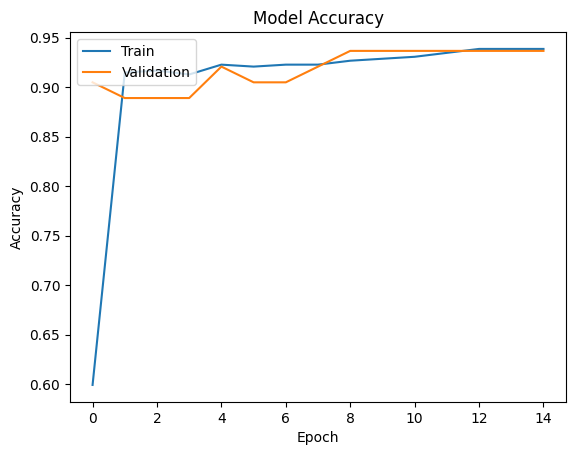

In [338]:
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [339]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.940476  0.940476   0.940511  0.940479


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


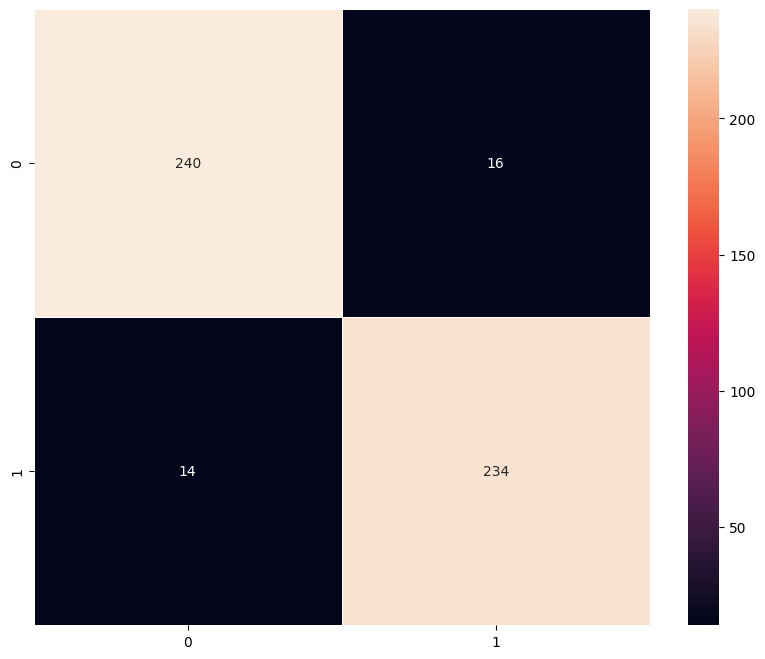

In [340]:
plot_confusion_matrix(model_1,X_train_normalized,y_train)

In [341]:
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.936508  0.936508   0.938214  0.936412


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


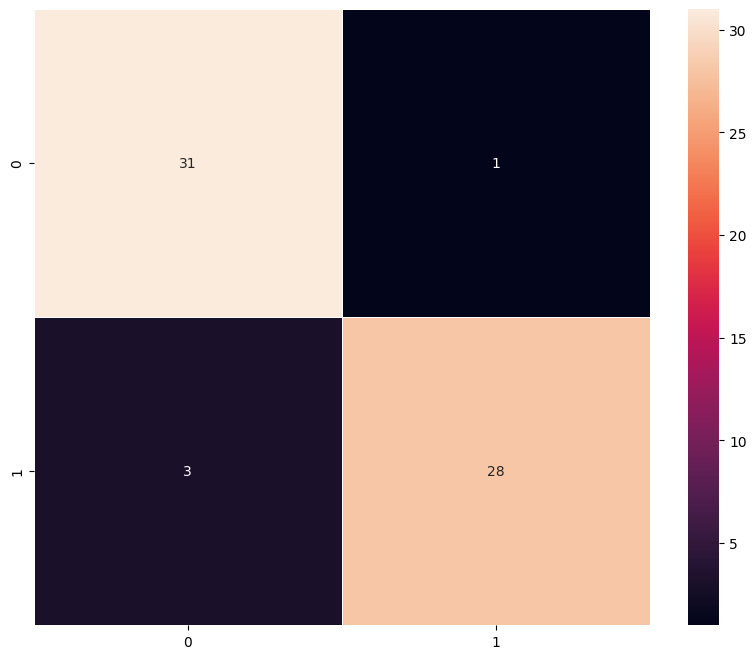

In [342]:
plot_confusion_matrix(model_1,X_val_normalized,y_val)

* This model has performed well but there are room for improvements

### Vizualizing the predictions

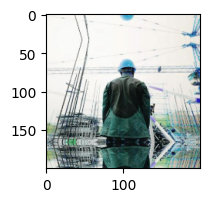

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
Predicted Label: 0
True Label: Label    1
Name: 62, dtype: int64


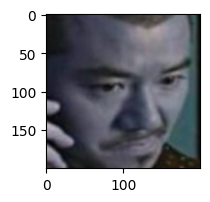

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Label: 0
True Label: Label    0
Name: 512, dtype: int64


In [343]:
# For index 2
plt.figure(figsize=(2,2))
plt.imshow(X_val[12])
plt.show()
prediction = model_1.predict(X_val_normalized[2].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[12]
print('True Label:', true_label)

# For index 33
plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
prediction = model_1.predict(X_val_normalized[2].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[33]
print('True Label:', true_label)

## Model 2: (VGG-16 (Base))

- We will be loading a pre-built architecture - **VGG16**, which was trained on the ImageNet dataset and is the runner-up in the ImageNet competition in 2014.

- For training VGG16, we will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten and a single dense layer.

In [344]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [345]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200,200,3))
vgg_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [346]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [347]:
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

# Adding a dense output layer
model_2.add(Dense(1, activation='sigmoid'))

In [348]:
opt=Adam(learning_rate=0.00001)
# Compile model
model_2.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy"])

In [349]:
# Generating the summary of the model
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [350]:
train_datagen = ImageDataGenerator()

In [351]:
# Epochs
epochs = 15
# Batch size
batch_size = 128

history_2 = model_2.fit(train_datagen.flow(X_train_normalized,y_train,
                                      batch_size=batch_size,
                                      seed=42,
                                      shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5033 - loss: 0.8390 - val_accuracy: 0.5079 - val_loss: 0.8152
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 332ms/step - accuracy: 0.5312 - loss: 0.7897 - val_accuracy: 0.5079 - val_loss: 0.8095
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 676ms/step - accuracy: 0.5269 - loss: 0.8034 - val_accuracy: 0.5079 - val_loss: 0.7931
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.5391 - loss: 0.7689 - val_accuracy: 0.5238 - val_loss: 0.7877
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 677ms/step - accuracy: 0.5000 - loss: 0.8011 - val_accuracy: 0.5238 - val_loss: 0.7721
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.5583 - loss: 0.7305 - val_accuracy: 0.5238 - val_loss: 0.7672
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 676ms/step - accuracy: 0.5505 - loss: 0.7524 - val_accuracy: 0.5397 - val_loss: 0.7530
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.4922 - loss: 0.7788 - val_accuracy: 0.5397 - val_loss: 0.

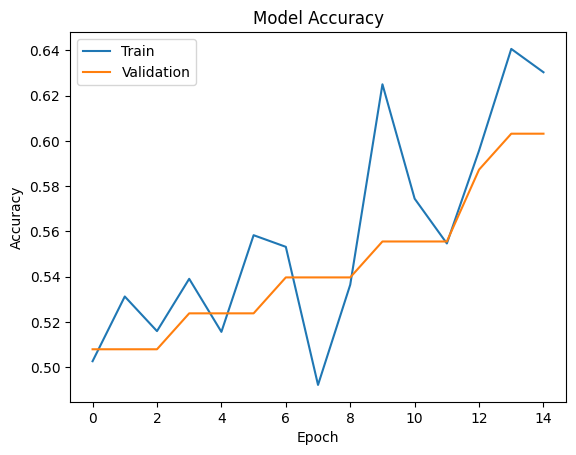

In [352]:
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [353]:
model_2_train_perf = model_performance_classification(model_2,X_train_normalized,y_train)

print("Train performance metrics")
print(model_2_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.638889  0.638889    0.71521  0.600441


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step


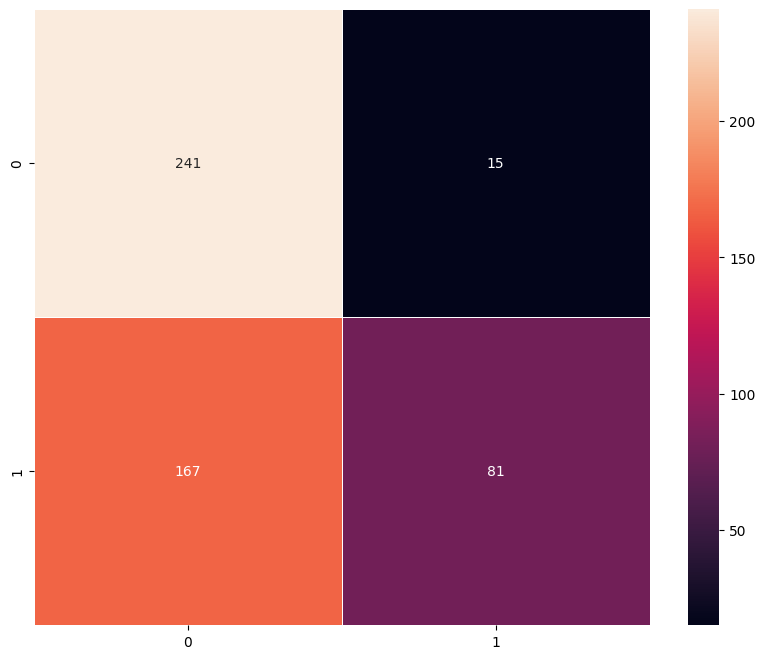

In [354]:
plot_confusion_matrix(model_2,X_train_normalized,y_train)

In [355]:
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_2_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.603175  0.603175   0.681162  0.550568


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


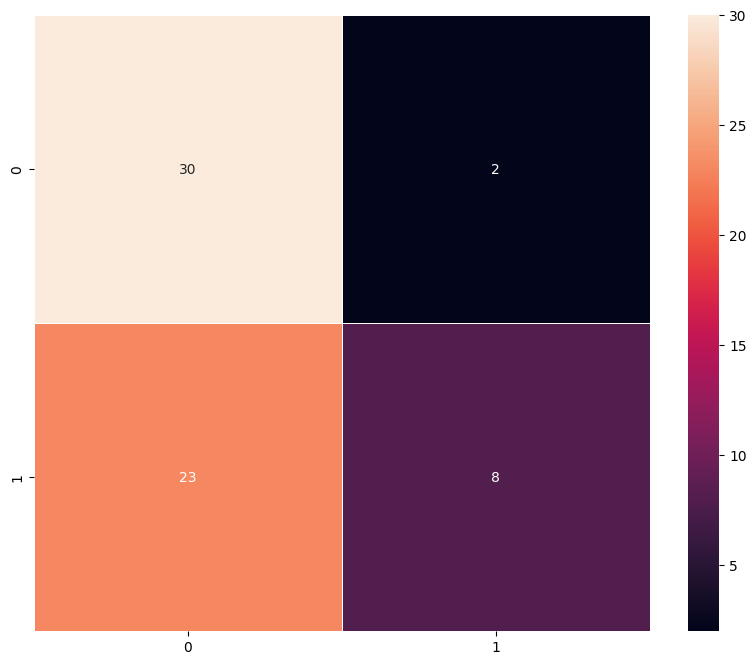

In [356]:
plot_confusion_matrix(model_2,X_val_normalized,y_val)

* The performance of this model has decreased compared to CNN model

### Visualizing the prediction:

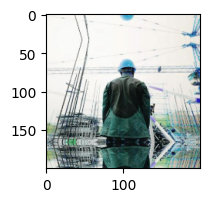

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
Predicted Label: 1
True Label: Label    1
Name: 62, dtype: int64


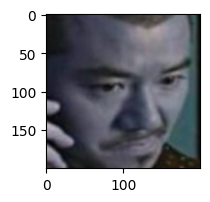

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Label: 1
True Label: Label    0
Name: 512, dtype: int64


In [357]:
plt.figure(figsize=(2,2))
plt.imshow(X_val[12])
plt.show()
prediction = model_2.predict(X_val_normalized[2].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[12]
print('True Label:', true_label)

plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
prediction = model_2.predict(X_val_normalized[2].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[33]
print('True Label:', true_label)

## Model 3: (VGG-16 (Base + FFNN))

* We will directly use the convolutional and pooling layers (VGG-16) and freeze their weights i.e. no training will be done on them.
* For classification, we will add a Flatten layer and a Feed Forward Neural Network.

In [358]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [359]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3.add(Flatten())

#Adding the Feed Forward neural network
model_3.add(Dense(128,activation='relu'))
model_3.add(Dropout(rate=0.4))
model_3.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_3.add(Dense(1, activation='sigmoid'))

In [360]:
opt = Adam(learning_rate=0.00001)

In [361]:
# Compile model
model_3.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy"])

In [362]:
# Generating the summary of the model
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,078,273 (65.15 MB)

 Trainable params: 2,363,585 (9.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [363]:

# Epochs
epochs = 15
# Batch size
batch_size = 128

history_3 = model_3.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.4505 - loss: 0.7616 - val_accuracy: 0.4603 - val_loss: 0.6858
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.5917 - loss: 0.7234 - val_accuracy: 0.5556 - val_loss: 0.6676
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 706ms/step - accuracy: 0.5684 - loss: 0.6860 - val_accuracy: 0.8571 - val_loss: 0.6177
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.6167 - loss: 0.6559 - val_accuracy: 0.9048 - val_loss: 0.6020
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 690ms/step - accuracy: 0.6788 - loss: 0.6176 - val_accuracy: 0.9365 - val_loss: 0.5586
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - accuracy: 0.7656 - loss: 0.5766 - val_accuracy: 0.9365 - val_loss: 0.5445
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 703ms/step - accuracy: 0.8015 - loss: 0.5567 - val_accuracy: 0.9683 - val_loss: 0.5032
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.7812 - loss: 0.5425 - val_accuracy: 0.9683 - val_loss: 0

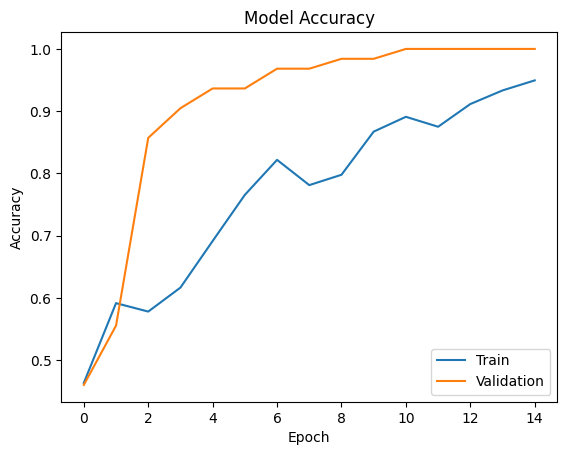

In [364]:
plt.plot(history_3.history['accuracy'])
plt.plot(history_3.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

In [365]:
model_3_train_perf = model_performance_classification(model_3, X_train_normalized,y_train)

print("Train performance metrics")
print(model_3_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.998016  0.998016   0.998024  0.998016


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step


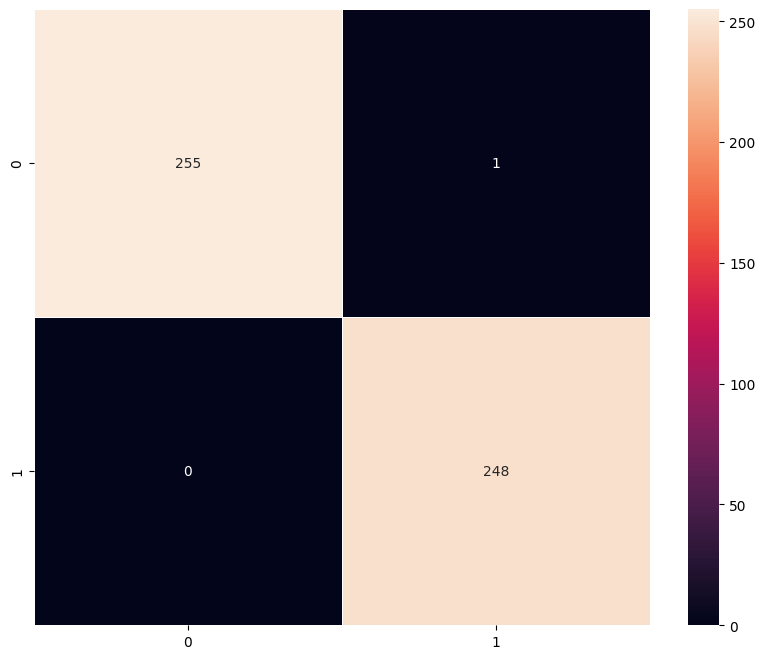

In [366]:
plot_confusion_matrix(model_3,X_train_normalized,y_train)

In [367]:
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_3_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


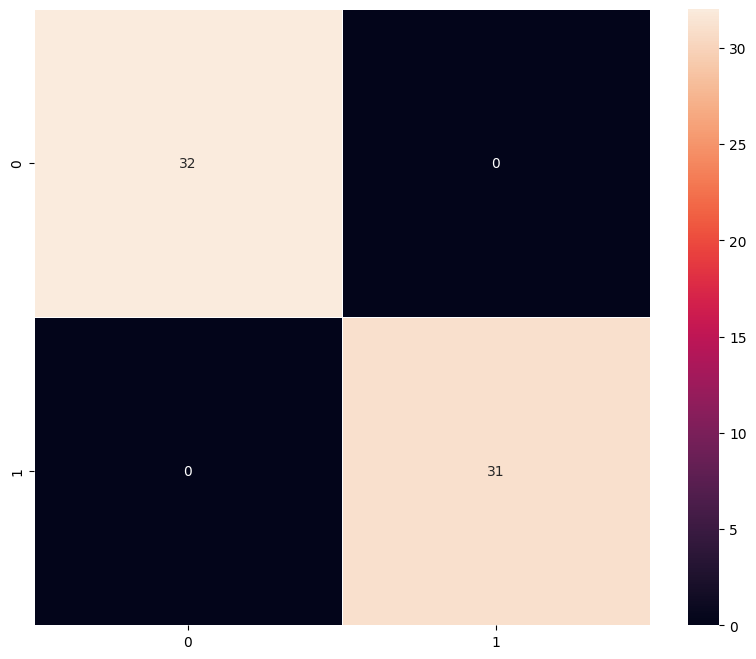

In [368]:
plot_confusion_matrix(model_3,X_val_normalized,y_val)

* This model has improved significantly compared to the base model

#### Visualizing the predictions

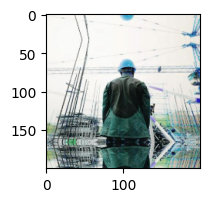

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step
Predicted Label: 0
True Label: Label    1
Name: 62, dtype: int64


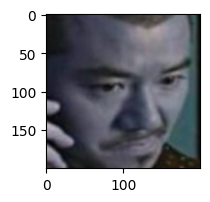

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Label: 0
True Label: Label    0
Name: 512, dtype: int64


In [369]:
# For index 2
plt.figure(figsize=(2,2))
plt.imshow(X_val[12])
plt.show()
prediction = model_3.predict(X_val_normalized[2].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[12]
print('True Label:', true_label)

# For index 33
plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
prediction = model_3.predict(X_val_normalized[2].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[33]
print('True Label:', true_label)

## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [370]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [371]:
model_4 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_4.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_4.add(Flatten())

#Adding the Feed Forward neural network
model_4.add(Dense(128,activation='relu'))
model_4.add(Dropout(rate=0.4))
model_4.add(Dense(32,activation='relu'))
# Adding a dense output layer
model_4.add(Dense(1, activation='sigmoid'))

In [372]:
# Using Adam Optimizer
opt = Adam(learning_rate=0.00001)

# Compile model
model_4.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=['accuracy'])

# Generating the summary of the model
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,078,273 (65.15 MB)

 Trainable params: 2,363,585 (9.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [373]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
                              rotation_range=25,
                              fill_mode='nearest',width_shift_range=0.2,height_shift_range=0.2,shear_range=0.3,zoom_range=0.4
                              )

In [374]:
# Epochs
epochs = 15
# Batch size
batch_size = 128

history_4 = model_4.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.5232 - loss: 0.7890 - val_accuracy: 0.5556 - val_loss: 0.6719
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.5391 - loss: 0.7449 - val_accuracy: 0.5873 - val_loss: 0.6593
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5261 - loss: 0.7303 - val_accuracy: 0.7937 - val_loss: 0.6290
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 0.6250 - loss: 0.6650 - val_accuracy: 0.7937 - val_loss: 0.6207
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5859 - loss: 0.6741 - val_accuracy: 0.9048 - val_loss: 0.5991
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.6583 - loss: 0.6515 - val_accuracy: 0.8889 - val_loss: 0.5925
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6549 - loss: 0.6260 - val_accuracy: 0.9206 - val_loss: 0.5727
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - accuracy: 0.6484 - loss: 0.6295 - val_accuracy: 0.9206 - val_loss: 0.5660
Epo

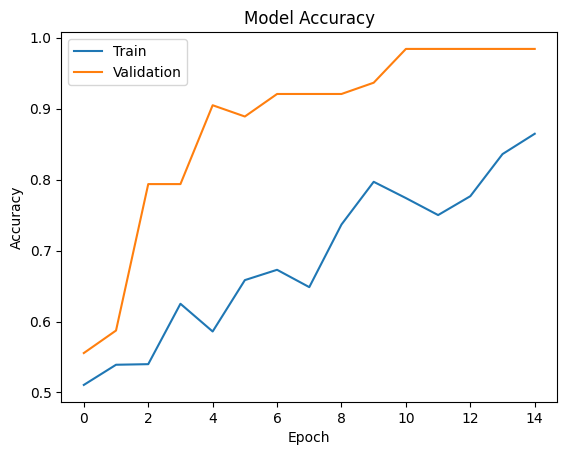

In [375]:
plt.plot(history_4.history['accuracy'])
plt.plot(history_4.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [376]:
model_4_train_perf = model_performance_classification(model_4, X_train_normalized,y_train)

print("Train performance metrics")
print(model_4_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.994048  0.994048   0.994055  0.994047


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step


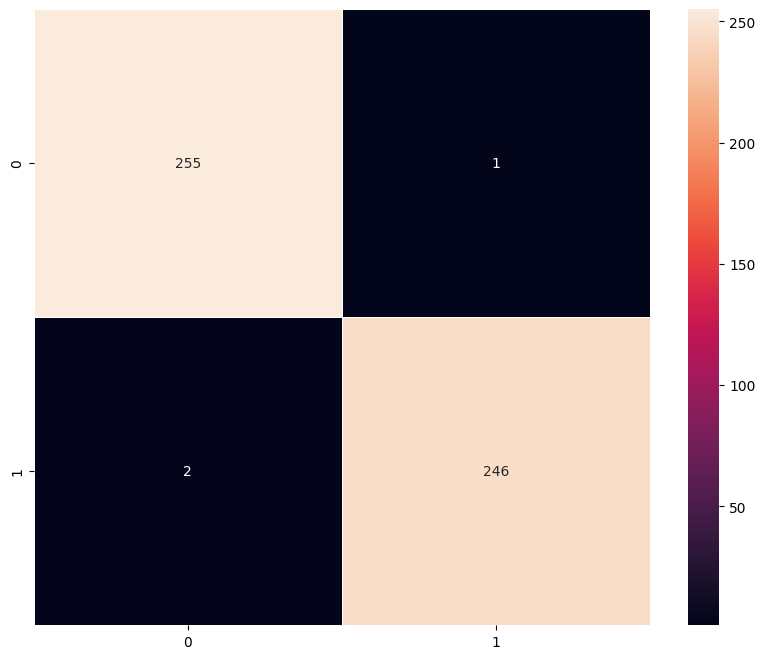

In [377]:
plot_confusion_matrix(model_4,X_train_normalized,y_train)

In [378]:
model_4_valid_perf = model_performance_classification(model_4, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_4_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 835ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.984127  0.984127   0.984608  0.984119


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


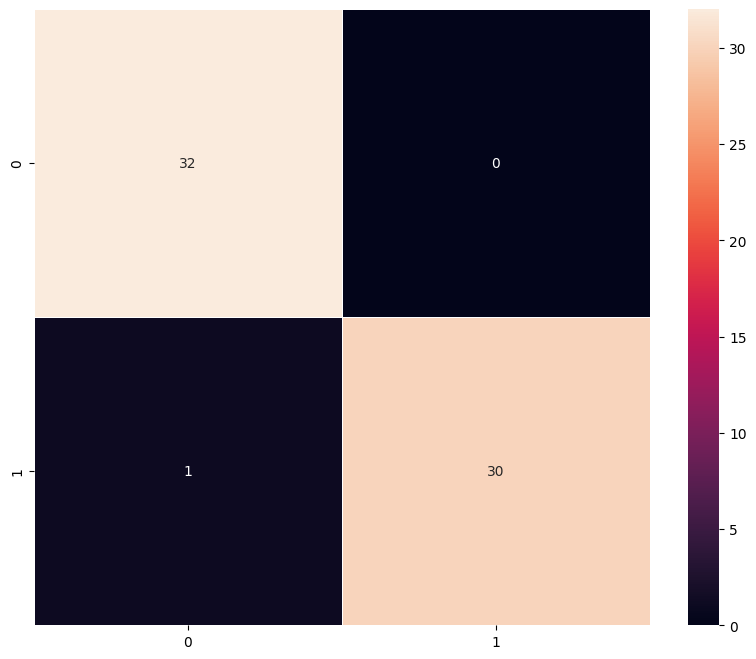

In [379]:
plot_confusion_matrix(model_4,X_val_normalized,y_val)

* This model's performance is similar to previous model, however, the previous model exceeded performance on validation dataset

#### Visualizing the predictions

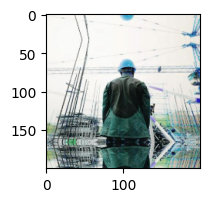

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step
Predicted Label: 0
True Label: Label    1
Name: 62, dtype: int64


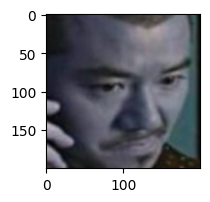

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Label: 0
True Label: Label    0
Name: 512, dtype: int64


In [380]:
plt.figure(figsize=(2,2))
plt.imshow(X_val[12]) #Complete the code to define the index
plt.show()
prediction = model_4.predict(X_val_normalized[2].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[12] #Complete the code to define the index
print('True Label:', true_label)

plt.figure(figsize=(2,2))
plt.imshow(X_val[33]) #Complete the code to define the index
plt.show()
prediction = model_4.predict(X_val_normalized[2].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[33] #Complete the code to define the index
print('True Label:', true_label)

# **Model Performance Comparison and Final Model Selection**

In [381]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base + FFNN)","VGG-16 (Base + FFNN + Data Aug)"
]

In [382]:
models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base + FFNN)","VGG-16 (Base + FFNN + Data Aug)"
]

In [383]:
models_train_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base + FFNN),VGG-16 (Base + FFNN + Data Aug)
Accuracy,0.940476,0.638889,0.998016,0.994048
Recall,0.940476,0.638889,0.998016,0.994048
Precision,0.940511,0.715210,0.998024,0.994055
F1 Score,0.940479,0.600441,0.998016,0.994047


In [384]:
models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base + FFNN),VGG-16 (Base + FFNN + Data Aug)
Accuracy,0.936508,0.603175,1.0,0.984127
Recall,0.936508,0.603175,1.0,0.984127
Precision,0.938214,0.681162,1.0,0.984608
F1 Score,0.936412,0.550568,1.0,0.984119


In [385]:
models_train_comp_df - models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base + FFNN),VGG-16 (Base + FFNN + Data Aug)
Accuracy,0.003968,0.035714,-0.001984,0.009921
Recall,0.003968,0.035714,-0.001984,0.009921
Precision,0.002297,0.034048,-0.001976,0.009447
F1 Score,0.004067,0.049872,-0.001984,0.009928


* VGG-16 (Base + FFNN) has achieved the highest performance in the training set. Also, it has achieved near perfect performance in validation set.
* We will move ahead with the VGG-16 (Base + FFNN) as our final model

## Test Performance

In [386]:
model_test_perf = model_performance_classification(model_3, X_test_normalized,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


In [387]:
model_test_perf

,Accuracy,Recall,Precision,F1 Score
0,0.984375,0.984375,0.984848,0.984371


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


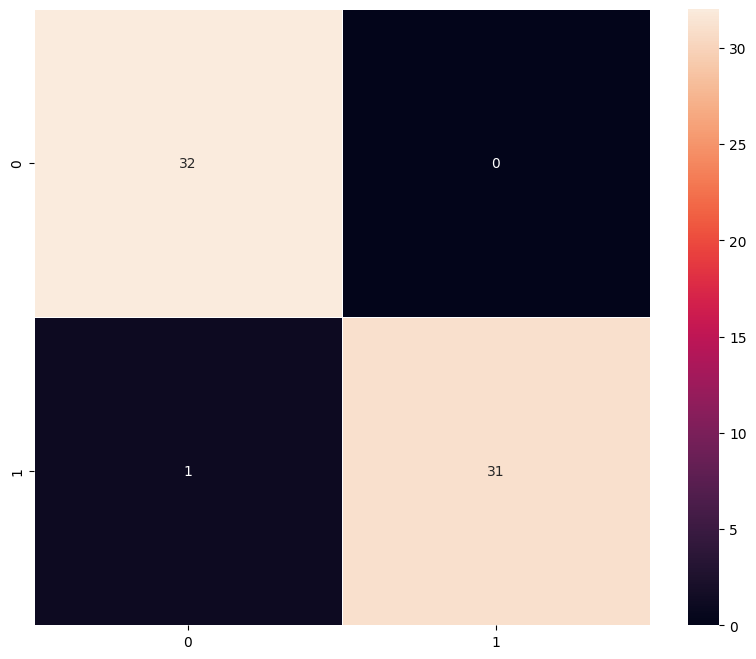

In [388]:
plot_confusion_matrix(model_3, X_test_normalized,y_test)

# **Actionable Insights & Recommendations**

* Adding a feed forward neural network on top of the VGG-16 model improved the performance significantly
* VGG-16 ( Base + FFNN + Data Augmentation) model also performed very well on both training and validation datasets
* These models can be further improved by training with different filter size and different number of filters
* Data Augmentation can be performed more and dropout_rate can be changed to improve the model performance
* Other Transfer Learning architectures can also be used to train the CNN model


<font size=5 color='blue'>Power Ahead!</font>
___